                               Experimento  accuracy  precision    recall  \
0                      Exp1 - MLP Baseline  0.840625   0.841341  0.840625   
1                    Exp2 - MLP + L2 forte  0.860000   0.860370  0.860000   
2              Exp3 - MLP + Early Stopping  0.821250   0.822044  0.821250   
3                Exp4 - MLP Melhor Esforco  0.861250   0.862824  0.861250   
4             Exp5 - SVM Baseline (linear)  0.735625   0.737908  0.735625   
5                  Exp6 - SVM + kernel RBF  0.812500   0.809968  0.812500   
6          Exp7 - SVM + Busca de C (C=100)  0.881875   0.883882  0.881875   
7  Exp8 - SVM Melhor Esforco (gamma=0.001)  0.875000   0.884437  0.875000   

   f1_score  
0  0.839096  
1  0.857450  
2  0.819237  
3  0.859499  
4  0.734157  
5  0.807222  
6  0.879784  
7  0.874153  


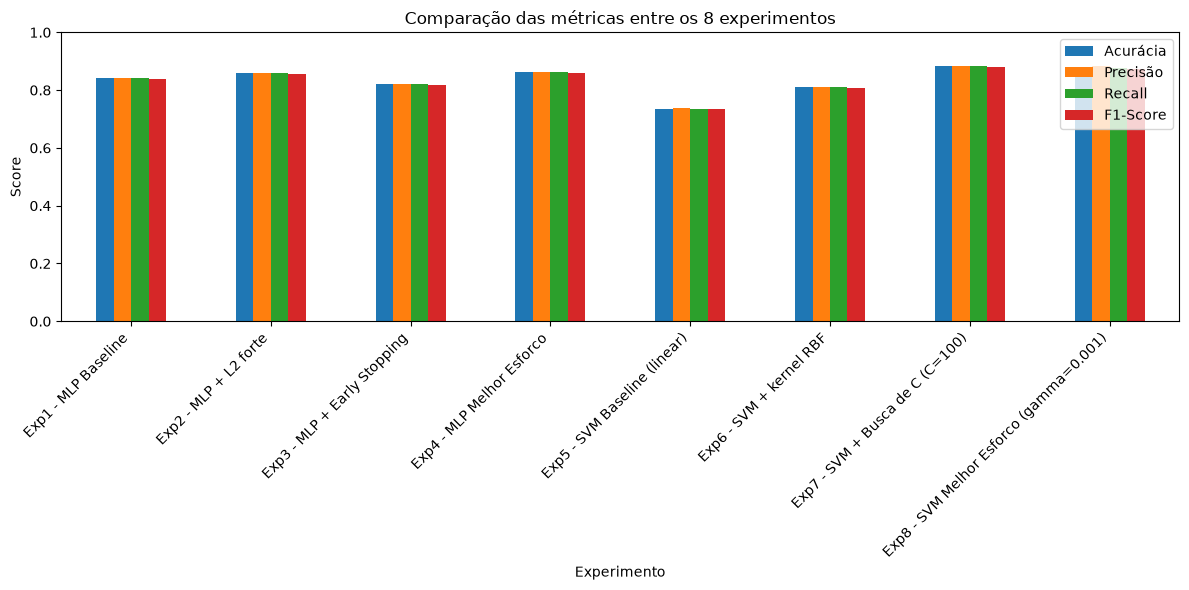


Melhor experimento (por F1-Score): Exp7 - SVM + Busca de C (C=100) (F1 = 0.8798)
Carregando 'glioma' (1400 imagens)...
  ... 200/1400 (0.2s decorridos)
  ... 400/1400 (0.3s decorridos)
  ... 600/1400 (0.4s decorridos)
  ... 800/1400 (0.6s decorridos)
  ... 1000/1400 (0.7s decorridos)
  ... 1200/1400 (0.9s decorridos)
  ... 1400/1400 (1.0s decorridos)
  'glioma' concluida em 1.0s
Carregando 'meningioma' (1400 imagens)...
  ... 200/1400 (0.2s decorridos)
  ... 400/1400 (0.3s decorridos)
  ... 600/1400 (0.5s decorridos)
  ... 800/1400 (0.7s decorridos)
  ... 1000/1400 (0.8s decorridos)
  ... 1200/1400 (1.0s decorridos)
  ... 1400/1400 (1.1s decorridos)
  'meningioma' concluida em 1.1s
Carregando 'notumor' (1400 imagens)...
  ... 200/1400 (0.1s decorridos)
  ... 400/1400 (0.3s decorridos)
  ... 600/1400 (0.4s decorridos)
  ... 800/1400 (0.7s decorridos)
  ... 1000/1400 (0.8s decorridos)
  ... 1200/1400 (1.0s decorridos)
  ... 1400/1400 (1.1s decorridos)
  'notumor' concluida em 1.1s
Carre

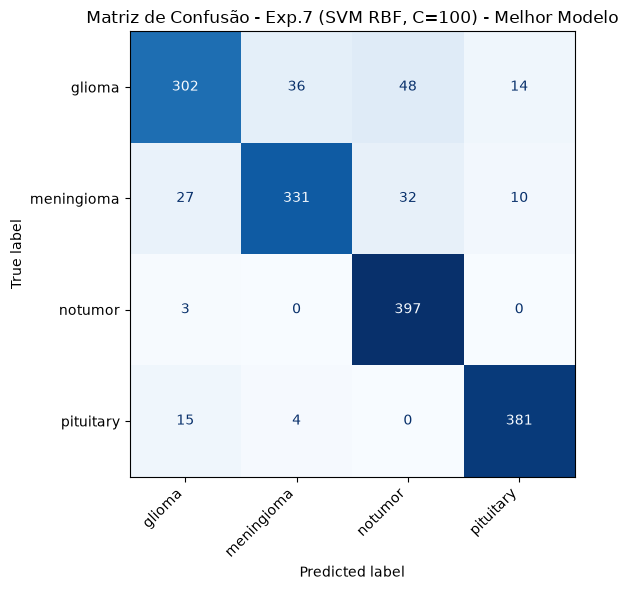


Matriz de confusão (linha = classe real, coluna = classe prevista):
            glioma  meningioma  notumor  pituitary
glioma         302          36       48         14
meningioma      27         331       32         10
notumor          3           0      397          0
pituitary       15           4        0        381


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from src import config
from src.data_loader import load_images_from_folder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Garante que a pasta de saida existe (aprendemos essa da vez passada)
os.makedirs("../results/figuras", exist_ok=True)

# ============================================================
# PARTE 1: Grafico comparativo -- le do CSV, NAO precisa retreinar nada
# ============================================================
df = pd.read_csv("../results/resultados_experimentos.csv")
print(df)

fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df.set_index("Experimento")[["accuracy", "precision", "recall", "f1_score"]]
df_plot.columns = ["Acurácia", "Precisão", "Recall", "F1-Score"]
df_plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Comparação das métricas entre os 8 experimentos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/figuras/comparacao_experimentos.png", dpi=150)
plt.show()

melhor = df.loc[df["f1_score"].idxmax()]
print(f"\nMelhor experimento (por F1-Score): {melhor['Experimento']} (F1 = {melhor['f1_score']:.4f})")

# ============================================================
# PARTE 2: Matriz de confusao do melhor modelo (Exp.7: SVM RBF, C=100, gamma='scale')
# -- precisa retreinar SO ESSE, nao os 8
# ============================================================
X, y, class_names = load_images_from_folder(config.TRAIN_DIR)
X_test, y_test, _ = load_images_from_folder(config.TEST_DIR)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=150, random_state=config.RANDOM_STATE)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

melhor_modelo = SVC(kernel="rbf", C=100, gamma="scale", random_state=config.RANDOM_STATE)
melhor_modelo.fit(X_train, y_train)
y_pred = melhor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão - Exp.7 (SVM RBF, C=100) - Melhor Modelo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/figuras/matriz_confusao_melhor_modelo.png", dpi=150)
plt.show()

print("\nMatriz de confusão (linha = classe real, coluna = classe prevista):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))